# Volcanic Change Detection: Reykjanes Peninsula, Iceland
### SDS210 – Programming with Spatial Data

This notebook implements a change detection workflow to identify and 
quantify landscape changes caused by the 2023–2024 Sundhnúkur eruptions 
on the Reykjanes Peninsula, Iceland.

Three research questions are investigated:
- **RQ1:** Where did the most significant landscape changes occur between 2023 and 2024?
- **RQ2:** How does embedding-based change detection compare to a traditional spectral approach?
- **RQ3:** Which critical infrastructure sites fall within the areas of highest detected landscape change?

## 2. Data Loading


In [1]:
# File paths
from pathlib import Path

# Raster reading and metadata
import rasterio
from rasterio.plot import show

# Numerical calculations
import numpy as np

# Tabular results
import pandas as pd
import geopandas as gpd

# Visualization
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

import xarray as xr
import rioxarray

In [2]:
# Paths
DATA_RAW       = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
OUTPUT_DIR     = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Raster files exported from GEE
EMB_2023 = DATA_RAW / "AEF_embedding_2023.tif"
EMB_2024 = DATA_RAW / "AEF_embedding_2024.tif"
S2_2023  = DATA_RAW / "S2_composite_2023.tif"
S2_2024  = DATA_RAW / "S2_composite_2024.tif"

# Vector files
BUILDINGS_PRE      = DATA_RAW / "buildings_pre_eruption.geojson"
BUILDINGS_POST     = DATA_RAW / "buildings_post_eruption.geojson"
BUILDINGS_COMBINED = DATA_PROCESSED / "buildings_combined.geojson"

# Study parameters
AOI_NAME  = "Reykjanes Peninsula, Iceland"
YEAR_PRE  = 2023
YEAR_POST = 2024
CHANGE_THRESHOLD = 0.95

print(f"Study area:   {AOI_NAME}")
print(f"Before/after: {YEAR_PRE} → {YEAR_POST}")

# Bounding box (WGS84)
AOI_BOUNDS = {
    "west":  -22.62,
    "east":  -22.15,
    "south":  63.80,
    "north":  63.95
}

Study area:   Reykjanes Peninsula, Iceland
Before/after: 2023 → 2024


In [3]:
# Metadata check of all four rasters
for filepath in [EMB_2023, EMB_2024, S2_2023, S2_2024]:
    with rasterio.open(filepath) as src:
        print(f"{filepath.name}")
        print(f"  CRS:   {src.crs}")
        print(f"  Bands: {src.count}")
        print(f"  Shape: {src.height} x {src.width}")

AEF_embedding_2023.tif
  CRS:   EPSG:32627
  Bands: 64
  Shape: 1723 x 2346
AEF_embedding_2024.tif
  CRS:   EPSG:32627
  Bands: 64
  Shape: 1723 x 2346
S2_composite_2023.tif
  CRS:   EPSG:32627
  Bands: 12
  Shape: 1723 x 2346
S2_composite_2024.tif
  CRS:   EPSG:32627
  Bands: 12
  Shape: 1723 x 2346


## 3. Inspection & Cleaning

### 3.1 Combine building footprints
Merging pre- and post-eruption OSM building datasets to get the most
complete picture of structures that existed before the eruptions. 


In [4]:
# Load both raw building datasets
buildings_pre  = gpd.read_file(DATA_RAW / "buildings_pre_eruption.geojson")
buildings_post = gpd.read_file(DATA_RAW / "buildings_post_eruption.geojson")

# Check CRS of both datasets
print(f"Pre-eruption CRS:  {buildings_pre.crs}")
print(f"Post-eruption CRS: {buildings_post.crs}")

# Combine and remove duplicates by OSM feature ID
buildings_combined = pd.concat([buildings_pre, buildings_post])
buildings_combined = buildings_combined.drop_duplicates(subset=["id"])

# Convert back to GeoDataFrame
buildings_combined = gpd.GeoDataFrame(buildings_combined, crs=buildings_pre.crs)

# Save to processed folder
buildings_combined.to_file(
    DATA_PROCESSED / "buildings_combined.geojson",
    driver="GeoJSON"
)

print(f"Pre-eruption buildings:  {len(buildings_pre)}")
print(f"Post-eruption buildings: {len(buildings_post)}")
print(f"Combined (no doubles):   {len(buildings_combined)}")

# Find buildings in pre that are NOT in post
# These are candidates for destroyed structures
destroyed_candidates = buildings_pre[
    ~buildings_pre["id"].isin(buildings_post["id"])
]

print(f"Buildings that were destroyed (removed from OSM): {len(destroyed_candidates)}")
print(destroyed_candidates[["id", "geometry"]])

Pre-eruption CRS:  EPSG:4326
Post-eruption CRS: EPSG:4326
Pre-eruption buildings:  1306
Post-eruption buildings: 1383
Combined (no doubles):   1390
Buildings that were destroyed (removed from OSM): 7
                 id                                           geometry
15    way/369408544  POLYGON ((-22.4527 63.88162, -22.45262 63.8814...
550   way/414495533  POLYGON ((-22.42082 63.8486, -22.4212 63.8486,...
656   way/414495646  POLYGON ((-22.42163 63.8555, -22.42141 63.8552...
662   way/414495653  POLYGON ((-22.41732 63.84852, -22.41768 63.848...
760   way/493268696  POLYGON ((-22.43586 63.83545, -22.43568 63.835...
1168  way/812387471  POLYGON ((-22.42187 63.84846, -22.42145 63.848...
1196  way/812390811  POLYGON ((-22.4364 63.83517, -22.43618 63.8349...


## 4. RQ1 — Embedding-based change

In [5]:
# Load embedding rasters
with rasterio.open(EMB_2023) as src:
    emb_2023 = src.read().astype(np.float32)
    emb_meta = src.profile

with rasterio.open(EMB_2024) as src:
    emb_2024 = src.read().astype(np.float32)

# Normalize along the band axis (axis=0) to make unit vectors
norm_2023 = np.linalg.norm(emb_2023, axis=0, keepdims=True)
norm_2024 = np.linalg.norm(emb_2024, axis=0, keepdims=True)

emb_2023 = emb_2023 / np.where(norm_2023 == 0, 1, norm_2023)
emb_2024 = emb_2024 / np.where(norm_2024 == 0, 1, norm_2024)

# Cosine similarity = dot product & embeddings = unit vectors
similarity = np.sum(emb_2023 * emb_2024, axis=0)
change_map = 1 - similarity

print(f"Min change: {np.nanmin(change_map):.4f}")
print(f"Max change: {np.nanmax(change_map):.4f}")

Min change: 0.0038
Max change: 0.5354


In [7]:
# Save change map for use in RQ3
CHANGE_MAP_PATH = OUTPUT_DIR / "rq1_change_map.tif"
emb_meta.update(count=1, dtype="float32")

with rasterio.open(CHANGE_MAP_PATH, "w", **emb_meta) as dst:
    dst.write(change_map.astype("float32"), 1)

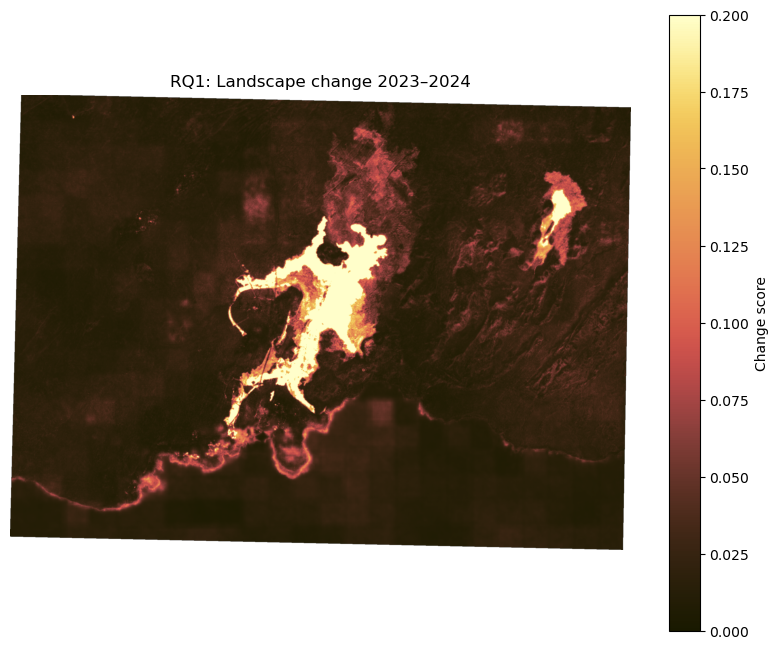

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(change_map, cmap=cmc.lajolla, vmin=0, vmax=0.2)
fig.colorbar(img, ax=ax, label="Change score")
ax.set_title(f"RQ1: Landscape change {YEAR_PRE}–{YEAR_POST}")
ax.axis("off")
fig.savefig(OUTPUT_DIR / "rq1_change_map.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. RQ2 — Spectral dNBR comparison

In [11]:
# Find NIR and SWIR2 band indices from band names
with rasterio.open(S2_2023) as src:
    band_names = list(src.descriptions)

nir_idx  = band_names.index("B8")  + 1
swir_idx = band_names.index("B12") + 1

with rasterio.open(S2_2023) as src:
    nir_2023  = src.read(nir_idx).astype(float)
    swir_2023 = src.read(swir_idx).astype(float)

with rasterio.open(S2_2024) as src:
    nir_2024  = src.read(nir_idx).astype(float)
    swir_2024 = src.read(swir_idx).astype(float)

with np.errstate(divide="ignore", invalid="ignore"):
    nbr_2023 = (nir_2023 - swir_2023) / (nir_2023 + swir_2023)
    nbr_2024 = (nir_2024 - swir_2024) / (nir_2024 + swir_2024)

# dNBR: after minus before
dnbr = nbr_2023 - nbr_2024

print(f"dNBR min:  {np.nanmin(dnbr):.4f}")
print(f"dNBR max:  {np.nanmax(dnbr):.4f}")

dNBR min:  -0.6816
dNBR max:  0.8536


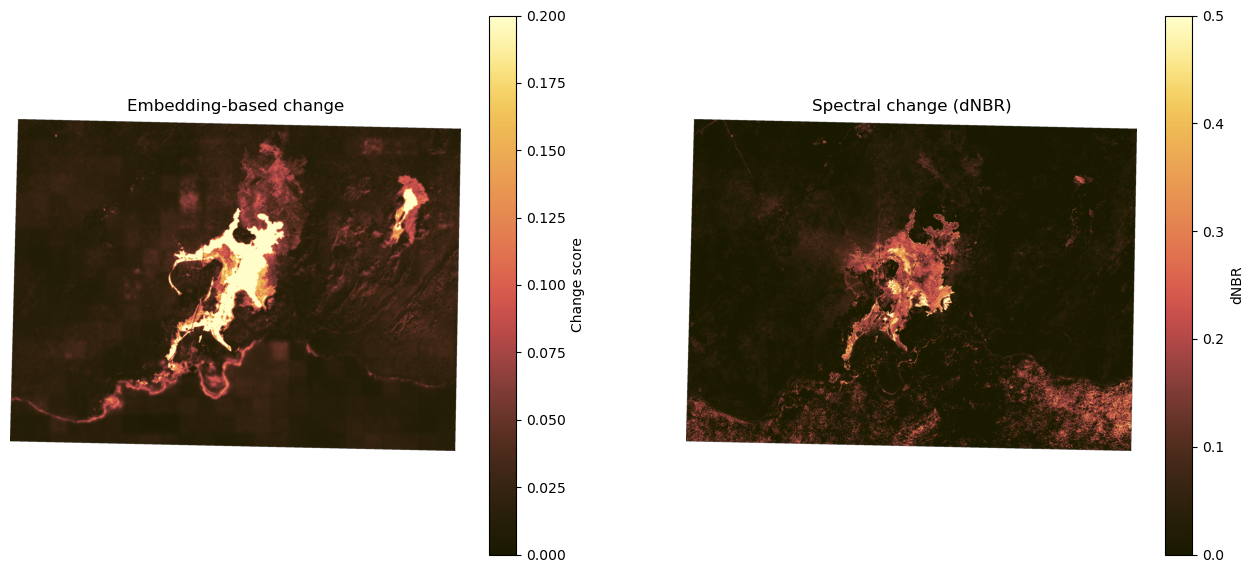

In [12]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

img1 = axs[0].imshow(change_map, cmap=cmc.lajolla, vmin=0, vmax=0.2)
fig.colorbar(img1, ax=axs[0], label="Change score")
axs[0].set_title("Embedding-based change")
axs[0].axis("off")

img2 = axs[1].imshow(dnbr, cmap=cmc.lajolla, vmin=0, vmax=0.5)
fig.colorbar(img2, ax=axs[1], label="dNBR")
axs[1].set_title("Spectral change (dNBR)")
axs[1].axis("off")

fig.savefig(OUTPUT_DIR / "rq2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. RQ3 — Infrastructure impact
## 7. Summary